VIDEO GAME SALES

John Esteban Polo Viteri A00412393

Eva Sophia Larrahondo Martinez A00096716

**Dataset elegido:** Global Video Game Sales (vgsales.csv)

**Justificacion:** 

Elegimos el dataset porque nos intereso el tema y el saber como preferencias por video juegos habia cambiado o aumentado dependiendo de los años.

PREGUNTAS GUIA

* ¿Como ha sido la evolución historica de las ventas globales de videojuegos a lo largo de las decadas y en que epoca tuvo su punto maximo?

* ¿Existen diferencias en las preferencias de generos de videojuegos entre las regiones?  
* ¿Cuales son las plataformas y distribuidores principales en ventas y cómo se distribuyen sus exitos?    
* ¿Como se comportan las ventas de los principales géneros a lo largo del tiempo y según las principales plataformas?  

Seccion 2: Carga y exploracion inicial

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# dataset
df = pd.read_csv(r"C:\Users\evaso\OneDrive\Desktop\Trabajo Eda\vgsales.csv")

# Silenciar warnings menores
import warnings
warnings.filterwarnings("ignore")

# ver el numero de filas y columnas, faltantes y residuales.
print(df.shape)
df.info()          
print(df.head())

print("\nvariables numéricas")
print(df.describe())

(16598, 11)
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      

El dataset tiene 16,598 filas y 11 columnas. Hay datos faltantes en las columnas Year y Publisher, además de que los dato de Year se tienen que convertir en enteros.

Seccion 3: Limpieza y preparacion de los datos

In [8]:
# duplicados
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados exactos: {duplicados}")

# faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())

df_clean = df.dropna(subset=['Year']).copy()
df_clean['Publisher'] = df_clean['Publisher'].fillna('desconocido')

# corregir los tipos de datos a enteron
df_clean['Year'] = df_clean['Year'].astype(int)

#  Creación de variables derivadas
# A) Agrupación por Década
df_clean['Decade'] = (df_clean['Year'] // 10) * 10
df_clean['Decade'] = df_clean['Decade'].astype(str) + 's'

# B) Categorización de ventas globales (Bajo, Medio, Alto, Éxito Masivo)
df_clean['Sales_Category'] = pd.qcut(
    df_clean['Global_Sales'],
    q=4,
    labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Éxito Masivo']
)

print("\n--- Estado del DataFrame tras la limpieza ---")
print(f"Filas restantes: {df_clean.shape[0]}")
df_clean.info()

Número de registros duplicados exactos: 0

Valores faltantes por columna:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

--- Estado del DataFrame tras la limpieza ---
Filas restantes: 16327
<class 'pandas.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Rank            16327 non-null  int64   
 1   Name            16327 non-null  str     
 2   Platform        16327 non-null  str     
 3   Year            16327 non-null  int64   
 4   Genre           16327 non-null  str     
 5   Publisher       16327 non-null  str     
 6   NA_Sales        16327 non-null  float64 
 7   EU_Sales        16327 non-null  float64 
 8   JP_Sales        16327 non-null  float64 
 9   Other_Sales     163

Se quitaron los registros con año faltante, para Publisher, se cambiaron los NA por la categoría "desconocido"

Creamos Decade para facilitar el análisis macro-temporal y Sales_Category mediante cuantiles para análisis categóricos.

Seccion 4: Analisis univariado

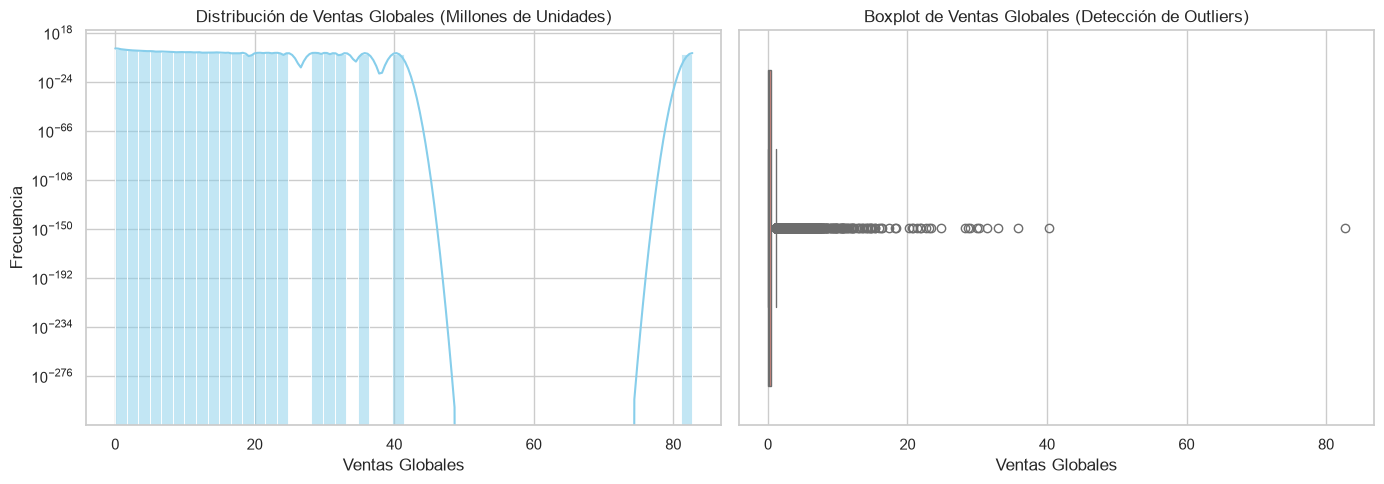

Media de Ventas Globales: 0.540 M
Mediana de Ventas Globales: 0.170 M
Asimetría (Skewness): 17.321


In [9]:
# Histograma con KDE y Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['Global_Sales'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Ventas Globales (Millones de Unidades)')
axes[0].set_xlabel('Ventas Globales')
axes[0].set_ylabel('Frecuencia')
axes[0].set_yscale('log')

sns.boxplot(x=df_clean['Global_Sales'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot de Ventas Globales (Detección de Outliers)')
axes[1].set_xlabel('Ventas Globales')

plt.tight_layout()
plt.show()

# tendecia central
media = df_clean['Global_Sales'].mean()
mediana = df_clean['Global_Sales'].median()
asimetria = df_clean['Global_Sales'].skew()

print(f"Media de Ventas Globales: {media:.3f} M")
print(f"Mediana de Ventas Globales: {mediana:.3f} M")
print(f"Asimetría (Skewness): {asimetria:.3f}")

La variable Global_Sales presenta una asimetría positiva. La gran mayoría de los títulos venden menos de 1 millón de copias, mientras que una minoría vende decenas de millones de unidades, desplazando la media hacia 0.54 M.

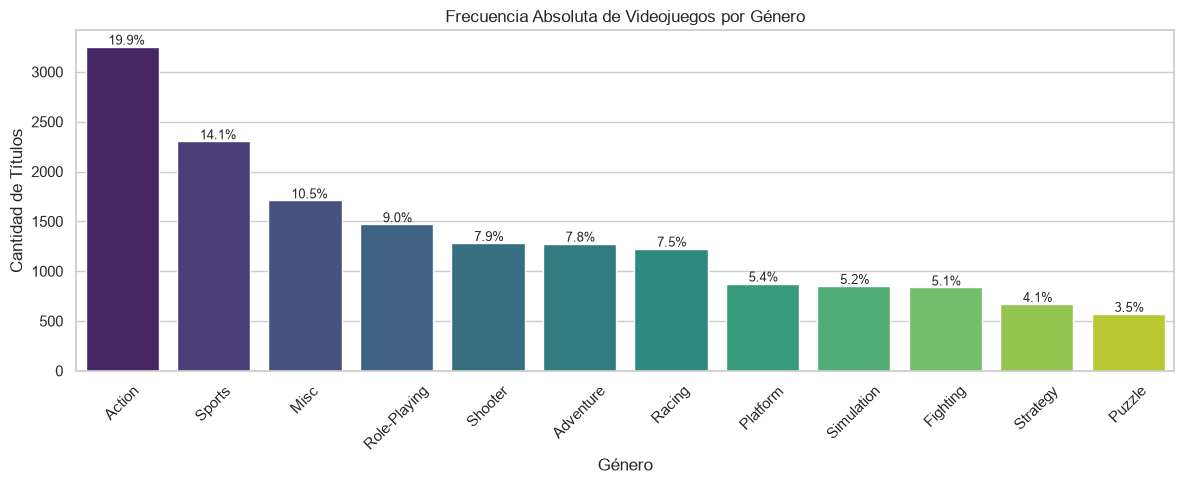

In [10]:
# Generos
plt.figure(figsize=(12, 5))
order_genre = df_clean['Genre'].value_counts().index

ax = sns.countplot(data=df_clean, x='Genre', order=order_genre, palette='viridis')
plt.title('Frecuencia Absoluta de Videojuegos por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Títulos')
plt.xticks(rotation=45)


total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 20
    ax.annotate(percentage, (x, y), size=9)

plt.tight_layout()
plt.show()

Los generos con mayor cantidad de títulos desarrollados son Action 20% y Sports 14%, seguidos por Misc y Role-Playing. Los generos con menor representación en la industria son Puzzle 3.5% y Strategy 4.1%.

Seccion 5: Analisis Bivariado

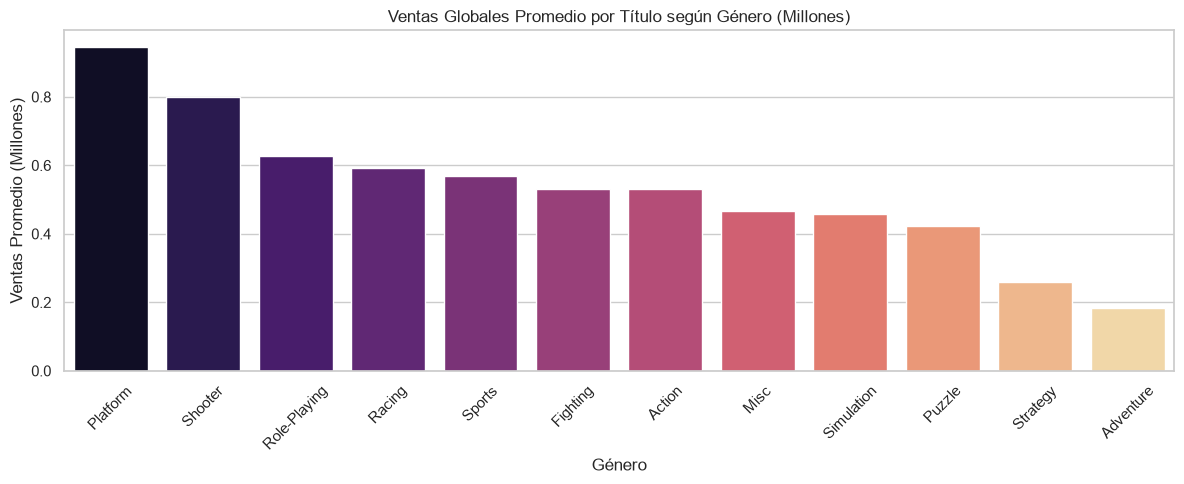

In [11]:
# Categórica vs Numérica - Ventas Globales Promedio por Género
plt.figure(figsize=(12, 5))
genre_sales = df_clean.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='magma')
plt.title('Ventas Globales Promedio por Título según Género (Millones)')
plt.xlabel('Género')
plt.ylabel('Ventas Promedio (Millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Aunque action es el genero con mas titulos publicados, el genero con mayor rendimiento comercial promedio por titulo es platform, seguido por shooter  y role playing. Eso puede significar que los juegos de plataformas y disparos logran un mayor rendimiento por proyecto publicado.

**Bivariado adicional (cat × num):** ¿Cómo varía la dispersión de ventas globales por título entre las plataformas mas frecuentes del catalogo? A diferencia del promedio por genero, aqui usamos un boxplot para ver la variabilidad y los valores atipicos dentro de cada plataforma.

In [12]:
# Bivariado 3: Categórica vs Numérica - Dispersión de Ventas Globales por Plataforma (Top 8 por cantidad de títulos)top_platforms = df_clean['Platform'].value_counts().head(8).indexdf_top_p = df_clean[df_clean['Platform'].isin(top_platforms)]plt.figure(figsize=(12, 6))order_plat = df_top_p.groupby('Platform')['Global_Sales'].median().sort_values(ascending=False).indexsns.boxplot(data=df_top_p, x='Platform', y='Global_Sales', order=order_plat, palette='crest')plt.title('Distribución de Ventas Globales por Plataforma (Top 8 por cantidad de títulos)')plt.xlabel('Plataforma')plt.ylabel('Ventas Globales (Millones)')plt.yscale('log')plt.tight_layout()plt.show()

Las medianas de ventas por título son similares y bajas en todas las plataformas (la mayoría de juegos vende poco), pero la cola de outliers es mucho más larga en plataformas como Wii y X360, que concentran algunos de los títulos más exitosos de la historia (p. ej. paquetes con consola incluida). Esto confirma que el éxito comercial masivo es un fenómeno de pocos títulos ("long tail"), independientemente de la plataforma.

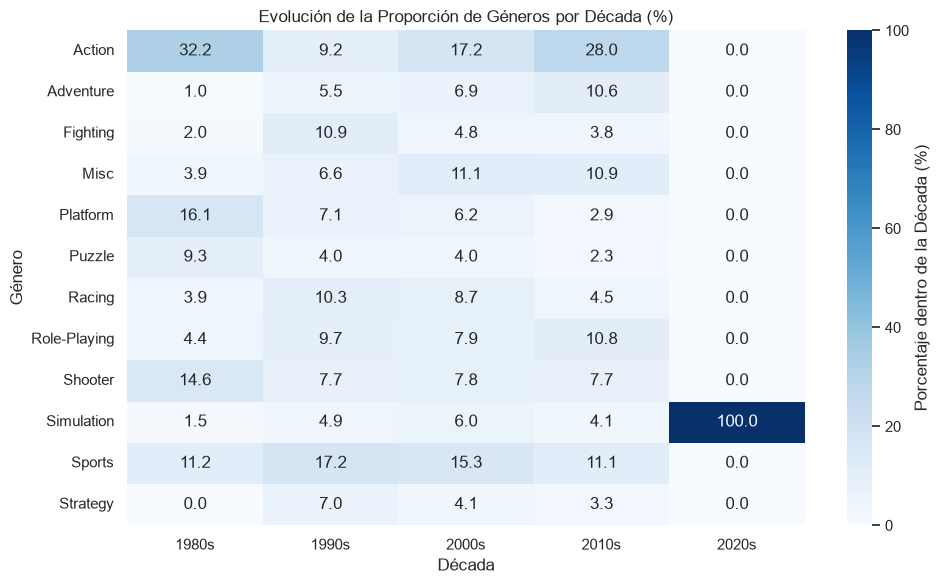

In [13]:
# Bivariado 2: Categórica vs Categórica - Matriz de Frecuencia (Crosstab + Heatmap)
ct = pd.crosstab(df_clean['Genre'], df_clean['Decade'], normalize='columns') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Porcentaje dentro de la Década (%)'})
plt.title('Evolución de la Proporción de Géneros por Década (%)')
plt.xlabel('Década')
plt.ylabel('Género')
plt.tight_layout()
plt.show()

El mapa de calor revela cambios estructurales en la preferencia de desarrollo: en los 1980s, el genero dominante fue platform. En los 1990s y 2000s, el genero action tomo crecio hasta eñ 22% de la producción en los 2010s.

**Bivariado adicional (cat × cat):** Creamos antes la variable derivada `Sales_Category` (cuartiles de ventas globales). Aquí la cruzamos con `Genre` para ver qué géneros concentran los títulos de mayor éxito comercial ("Éxito Masivo") frente a los de bajo desempeño.

In [14]:
# Bivariado 4: Categórica vs Categórica - Género vs Categoría de Ventas (usa la variable derivada Sales_Category)ct_cat = pd.crosstab(df_clean['Genre'], df_clean['Sales_Category'], normalize='columns') * 100plt.figure(figsize=(10, 7))sns.heatmap(ct_cat, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Porcentaje dentro de la categoría (%)'})plt.title('Distribución de Géneros según Categoría de Ventas (Cuartiles)')plt.xlabel('Categoría de Ventas')plt.ylabel('Género')plt.tight_layout()plt.show()

El género Shooter duplica su participación al pasar de 'Bajo' (6.6%) a 'Éxito Masivo' (11.0%), y Platform crece de 3.5% a 7.8%, mostrando que estos géneros producen relativamente pocos títulos pero con alta probabilidad de convertirse en exitos masivos. Adventure y Strategy pierden (2.4% y 2.2%), son generos con ventas mucho mas bajas.

Seccion 6: Analisis Multivariado y Correlaciones

In [15]:
# Multivariado 1: Matriz de Correlación de Pearsonnumeric_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']corr_matrix = df_clean[numeric_cols].corr()plt.figure(figsize=(8, 6))sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')plt.title('Matriz de Correlación de Pearson entre Regiones y Ventas Globales')plt.tight_layout()plt.show()

Norteamerica presenta la correlacion mas alta con las ventas globales , lo que confirma que el mercado norteamericano es el principal motor comercial en el mundo. Europa muestra una correlacion muy fuerte con el resto del mundo y con las ventas globales .Japon  presenta el comportamiento mas variable

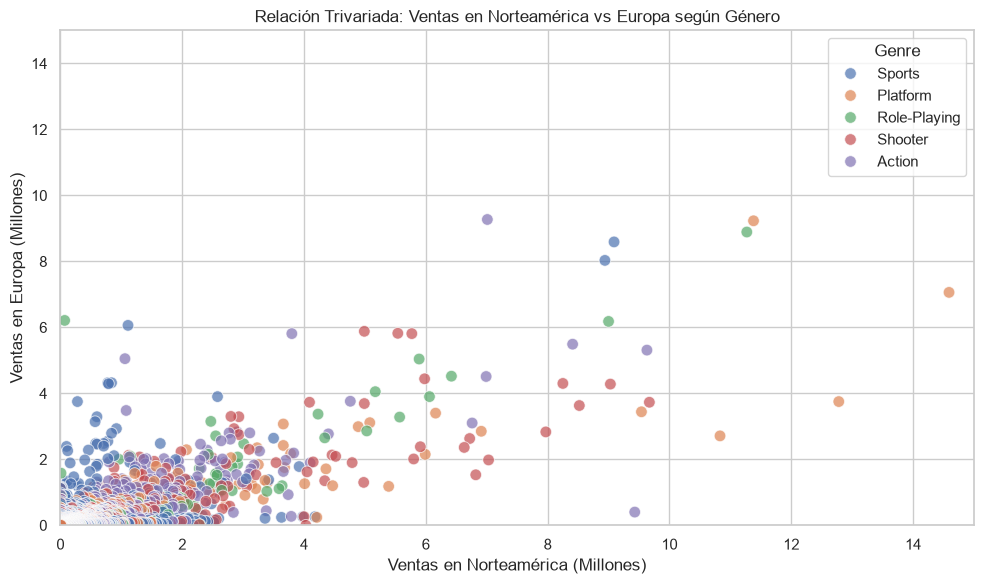

In [ ]:
# Multivariado 2: Scatter Plot Trivariado
top_genres = ['Action', 'Sports', 'Shooter', 'Role-Playing', 'Platform']
df_top_g = df_clean[df_clean['Genre'].isin(top_genres)]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_top_g,
    x='NA_Sales',
    y='EU_Sales',
    hue='Genre',
    alpha=0.7,
    s=70
)
plt.title('Relación Trivariada: Ventas en Norteamérica vs Europa según Género')
plt.xlabel('Ventas en Norteamérica (Millones)')
plt.ylabel('Ventas en Europa (Millones)')
plt.xlim(0, 15)
plt.ylim(0, 15)
plt.tight_layout()
plt.show()

Existe una alineacion lineal clara entre el exito comercial en Norteamerica y Europa para la mayoria de los titulos de Action, Sports y Shooter. Los superventas en ambas regiones son de deportes y disparos.

Seccion 7: Analisis Temporal

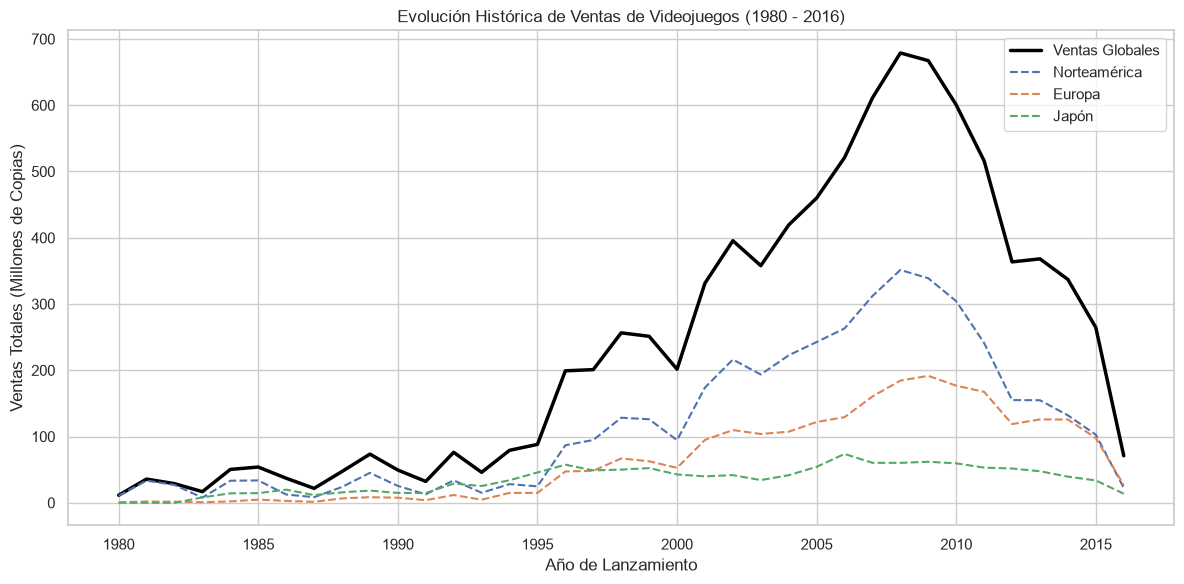

In [ ]:
yearly_sales = df_clean.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales']].sum().reset_index()

# Hasta 2016
yearly_sales = yearly_sales[yearly_sales['Year'] <= 2016]

plt.figure(figsize=(12, 6))
plt.plot(yearly_sales['Year'], yearly_sales['Global_Sales'], label='Ventas Globales', color='black', linewidth=2.5)
plt.plot(yearly_sales['Year'], yearly_sales['NA_Sales'], label='Norteamérica', linestyle='--')
plt.plot(yearly_sales['Year'], yearly_sales['EU_Sales'], label='Europa', linestyle='--')
plt.plot(yearly_sales['Year'], yearly_sales['JP_Sales'], label='Japón', linestyle='--')

plt.title('Evolución Histórica de Ventas de Videojuegos (1980 - 2016)')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas Totales (Millones de Copias)')
plt.legend()
plt.tight_layout()
plt.show()

La industria alcanzo su punto maximo de ventas fisicas cerca del año 2008 superando los 670 m de unidades vendidas en un año, impulsado por la generación de consolas Wii, Xbox 360 y PS3.

Hay una caida en el registro de copias fisicas a partir de 2011, sucedio por la distribucion de los juegos digitales y los juegos moviles.

Seccion 8: Sintesis de Hallazgos

# 1. Pocos juegos venden muchísimo
La mayoría de los videojuegos vende poco, mientras que unos pocos juegos muy famosos concentran gran parte de las ventas.


# 2. Hacer más juegos no significa vender más

**Action** es el género con más juegos, pero **Platform** y **Shooter** venden más en promedio por juego.

# 3. Shooter y Platform pueden tener mucho éxito

Estos géneros tienen una mayor presencia entre los juegos con ventas muy altas.

# 4. Norteamérica es el mercado más importante

Las ventas en Norteamérica son las que más se relacionan con las ventas globales. Europa también tiene una relación importante, Japón se comporta de manera diferente.

# 5. Las ventas físicas comenzaron a disminuir

Las ventas de juegos físicos tuvieron su mejor momento entre **2008 y 2009** y comenzaron a disminuir desde **2011**, debido al crecimiento de los juegos digitales y móviles.

# 6. Norteamérica y Europa tienen resultados parecidos

Cuando un juego vende bien en Norteamérica, normalmente también vende bien en Europa, especialmente en los géneros **Sports** y **Shooter**.


Declaración de uso de IA generativa

En cumplimiento de la Política Nivel 3 del curso, declaramos el uso de herramientas de IA generativa (Claude) de la siguiente manera:- **Tareas apoyadas por IA:** revisión del notebook

-https://claude.ai/share/a6b058f8-2689-4f83-9208-376af94cce8b

-https://claude.ai/share/0c5c2d98-8356-4100-9f33-b1eeebd1d563